#### Section 1: Data Analysis

In [31]:
# Import libraries for data handling, visualization, preprocessing, and neural networks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set(style="darkgrid")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [32]:
# Reproducibility and Device
# Set random seeds and detect whether GPU is available
# Helps make results more consistent and uses GPU if available

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [33]:
# Configuration
# Define key experimental parameters
# Keeping them in one place makes the notebook easier to manage and update

WINDOW_SIZE = 20        # number of past timesteps used as input
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

print("Window size:", WINDOW_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Window size: 20
Batch size: 64
Epochs: 20
Learning rate: 0.001


In [34]:
# Load dataset
# Load EUR/USD 5-minute data
# This is the base dataset for forecasting

DATA_PATH = "/kaggle/input/datasets/tanveerdalal/eurusd-5min-bid/EURUSD_5 Mins_Bid_2025.10.01_2026.03.31.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (36984, 6)


,Time (EET),Open,High,Low,Close,Volume
0,2025.10.01 00:00:00,1.17325,1.17339,1.17325,1.17339,34.53
1,2025.10.01 00:05:00,1.17341,1.17350,1.17338,1.17343,33.60
2,2025.10.01 00:10:00,1.17343,1.17348,1.17328,1.17335,103.47
3,2025.10.01 00:15:00,1.17336,1.17369,1.17334,1.17345,120.00
4,2025.10.01 00:20:00,1.17344,1.17349,1.17341,1.17349,115.35


In [35]:
# Clean time column
# Convert time column to datetime and sort data

df = df.rename(columns={"Time (EET)": "Time"})
df["Time"] = pd.to_datetime(df["Time"])

df = df.sort_values("Time").reset_index(drop=True)

print("Time range:", df["Time"].min(), "to", df["Time"].max())

Time range: 2025-10-01 00:00:00 to 2026-03-31 23:55:00


In [36]:
# Create target (next-step return)
# Calculate percentage return of closing price
# Returns are more stable and suitable for modeling than raw prices

df["return"] = df["Close"].pct_change().shift(-1)

In [37]:
# Feature engineering
# Create additional features to help model learn patterns
# Raw OHLC data does not capture trends and volatility well

# Log return
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# Price range (volatility within candle)
df["range"] = df["High"] - df["Low"]

# Candle body (direction strength)
df["body"] = df["Close"] - df["Open"]

# Moving averages
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_10"] = df["Close"].rolling(10).mean()

# Rolling volatility
df["volatility_5"] = df["Close"].rolling(5).std()

In [38]:
# Remove missing values

df = df.dropna().reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (36974, 13)


In [39]:
# Define feature and target columns
# Select input features and target variable

feature_columns = [
    "Open", "High", "Low", "Close",
    "log_return", "range", "body",
    "ma_5", "ma_10",
    "volatility_5"
]

target_column = "return"

print("Number of features:", len(feature_columns))

Number of features: 10


In [40]:
print(df[feature_columns + [target_column]].describe())

               Open          High           Low         Close    log_return  \
count  36974.000000  36974.000000  36974.000000  36974.000000  3.697400e+04   
mean       1.167138      1.167313      1.166963      1.167138 -4.236554e-07   
std        0.011637      0.011640      0.011633      0.011637  2.413552e-04   
min        1.141150      1.141210      1.141080      1.141110 -6.052540e-03   
25%        1.158680      1.158880      1.158500      1.158680 -1.103870e-04   
50%        1.164790      1.164940      1.164640      1.164790  0.000000e+00   
75%        1.175420      1.175597      1.175270      1.175430  1.094788e-04   
max        1.205610      1.208220      1.203940      1.205600  7.553882e-03   

              range          body          ma_5         ma_10  volatility_5  \
count  36974.000000  3.697400e+04  36974.000000  36974.000000  36974.000000   
mean       0.000350 -9.422838e-07      1.167139      1.167140      0.000209   
std        0.000273  2.760330e-04      0.011634    

#### Section 2: Split, Scaling & Sequence

In [41]:
# Time-based split
# Split data into train, validation, and test sets
# Prevent future data from leaking into training

data_size = len(df)

train_size = int(0.7 * data_size)
val_size = int(0.15 * data_size)

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (25881, 13)
Validation: (5546, 13)
Test: (5547, 13)


In [42]:
# Feature scaling
# Standardize input features
# Neural networks require normalized inputs

from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()

feature_scaler.fit(train_df[feature_columns])

train_scaled = feature_scaler.transform(train_df[feature_columns])
val_scaled = feature_scaler.transform(val_df[feature_columns])
test_scaled = feature_scaler.transform(test_df[feature_columns])

In [43]:
# Target scaling
# Standardize the target variable (returns)
# Prevent scale mismatch between input and output

target_scaler = StandardScaler()

target_scaler.fit(train_df[[target_column]])

train_targets = target_scaler.transform(train_df[[target_column]]).flatten()
val_targets = target_scaler.transform(val_df[[target_column]]).flatten()
test_targets = target_scaler.transform(test_df[[target_column]]).flatten()

print("Target range (scaled):", train_targets.min(), train_targets.max())

Target range (scaled): -21.958729935366023 26.01032804158537


In [44]:
# Sequence creation

WINDOW_SIZE = 20

def create_sequences(data, targets, window_size):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(targets[i])

    return np.array(X), np.array(y)

In [45]:
# Create sequences

X_train, y_train = create_sequences(train_scaled, train_targets, WINDOW_SIZE)
X_val, y_val = create_sequences(val_scaled, val_targets, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, test_targets, WINDOW_SIZE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (25861, 20, 10)
y_train shape: (25861,)


In [46]:
# Verification checks

print("Timesteps:", X_train.shape[1])
print("Features:", X_train.shape[2])

print("y_train min/max:", y_train.min(), y_train.max())

Timesteps: 20
Features: 10
y_train min/max: -21.958729935366023 26.01032804158537


#### Section 3: Dense Neural Network

In [47]:
# Flatten sequences
# Convert [samples, timesteps, features] → [samples, features]

X_train_dense = X_train.reshape(X_train.shape[0], -1)
X_val_dense = X_val.reshape(X_val.shape[0], -1)
X_test_dense = X_test.reshape(X_test.shape[0], -1)

print("Dense input shape:", X_train_dense.shape)

Dense input shape: (25861, 200)


In [48]:
import torch

# Convert to tensors

X_train_dense_t = torch.tensor(X_train_dense, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_dense_t = torch.tensor(X_val_dense, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_dense_t = torch.tensor(X_test_dense, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [49]:
import torch.nn as nn

# Dense Model

class DenseRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [50]:
import torch.optim as optim

# Initialize model

input_dim = X_train_dense.shape[1]

dense_model = DenseRegressor(input_dim).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(dense_model.parameters(), lr=LEARNING_RATE)

print(dense_model)

DenseRegressor(
  (net): Sequential(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [51]:
from torch.utils.data import TensorDataset, DataLoader

# DataLoaders

train_dataset_dense = TensorDataset(X_train_dense_t, y_train_t)
val_dataset_dense = TensorDataset(X_val_dense_t, y_val_t)

train_loader_dense = DataLoader(train_dataset_dense, batch_size=BATCH_SIZE, shuffle=False)
val_loader_dense = DataLoader(val_dataset_dense, batch_size=BATCH_SIZE, shuffle=False)

In [52]:
def train_regression_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20, patience=5):
    
    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = criterion(preds, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}: Train {train_loss:.6f}, Val {val_loss:.6f}", flush=True)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_state)
    return history

In [53]:
history_dense = train_regression_model(
    dense_model,
    train_loader_dense,
    val_loader_dense,
    criterion,
    optimizer,
    DEVICE,
    EPOCHS
)

Epoch 1: Train 1.013437, Val 1.248380
Epoch 2: Train 1.001966, Val 1.249818
Epoch 3: Train 0.998013, Val 1.251626
Epoch 4: Train 0.995779, Val 1.256800
Epoch 5: Train 0.991987, Val 1.264593
Epoch 6: Train 0.987241, Val 1.274921
Early stopping triggered


In [54]:
dense_model.eval()

with torch.no_grad():
    y_pred_dense_scaled = dense_model(X_test_dense_t.to(DEVICE)).cpu().numpy().flatten()

y_true_dense_scaled = y_test_t.cpu().numpy().flatten()

# Convert back to original scale
y_pred_dense = target_scaler.inverse_transform(y_pred_dense_scaled.reshape(-1, 1)).flatten()
y_true_dense = target_scaler.inverse_transform(y_true_dense_scaled.reshape(-1, 1)).flatten()

mae_dense = mean_absolute_error(y_true_dense, y_pred_dense)
rmse_dense = np.sqrt(mean_squared_error(y_true_dense, y_pred_dense))

print("Dense MAE:", mae_dense)
print("Dense RMSE:", rmse_dense)

Dense MAE: 0.00022125347459223121
Dense RMSE: 0.00034422938934938985


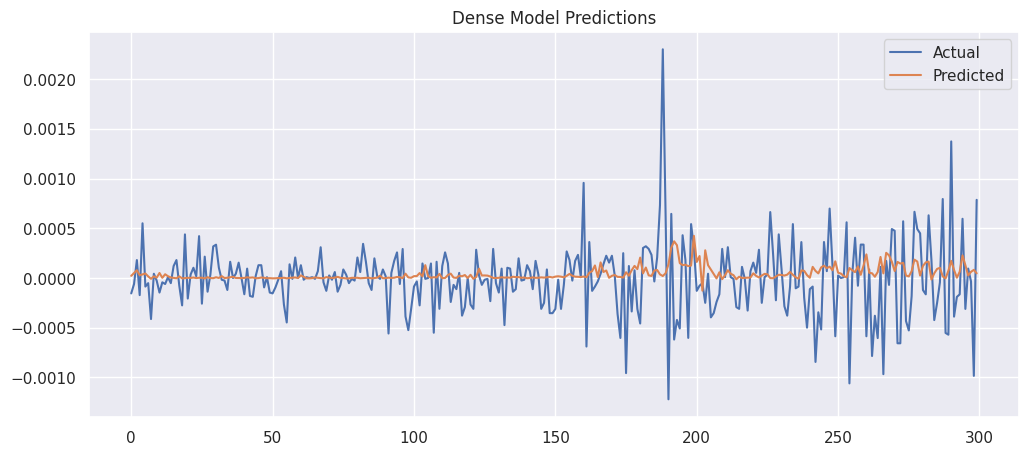

In [55]:
plt.figure(figsize=(12,5))
plt.plot(y_true_dense[:300], label="Actual")
plt.plot(y_pred_dense[:300], label="Predicted")
plt.title("Dense Model Predictions")
plt.legend()
plt.show()

#### Section 4: LSTM Model

In [56]:
# Convert sequence data to tensors

X_train_seq_t = torch.tensor(X_train, dtype=torch.float32)
y_train_seq_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_seq_t = torch.tensor(X_val, dtype=torch.float32)
y_val_seq_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_seq_t = torch.tensor(X_test, dtype=torch.float32)
y_test_seq_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train_seq_t shape:", X_train_seq_t.shape)
print("y_train_seq_t shape:", y_train_seq_t.shape)

X_train_seq_t shape: torch.Size([25861, 20, 10])
y_train_seq_t shape: torch.Size([25861, 1])


In [57]:
from torch.utils.data import TensorDataset, DataLoader

# DataLoaders for LSTM

train_dataset_lstm = TensorDataset(X_train_seq_t, y_train_seq_t)
val_dataset_lstm = TensorDataset(X_val_seq_t, y_val_seq_t)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)

In [58]:
# LSTM Regressor

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = hidden[-1]
        out = self.fc(out)
        return out

In [59]:
# Initialize LSTM model

input_size = X_train.shape[2]

lstm_model = LSTMRegressor(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [60]:
# Train LSTM model

history_lstm = train_regression_model(
    model=lstm_model,
    train_loader=train_loader_lstm,
    val_loader=val_loader_lstm,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    patience=5
)

Epoch 1: Train 1.002640, Val 1.255492
Epoch 2: Train 1.000942, Val 1.258346
Epoch 3: Train 1.000152, Val 1.251660
Epoch 4: Train 0.999404, Val 1.252128
Epoch 5: Train 0.998641, Val 1.253377
Epoch 6: Train 0.998040, Val 1.255584
Epoch 7: Train 0.997182, Val 1.257173
Epoch 8: Train 0.996403, Val 1.259032
Early stopping triggered


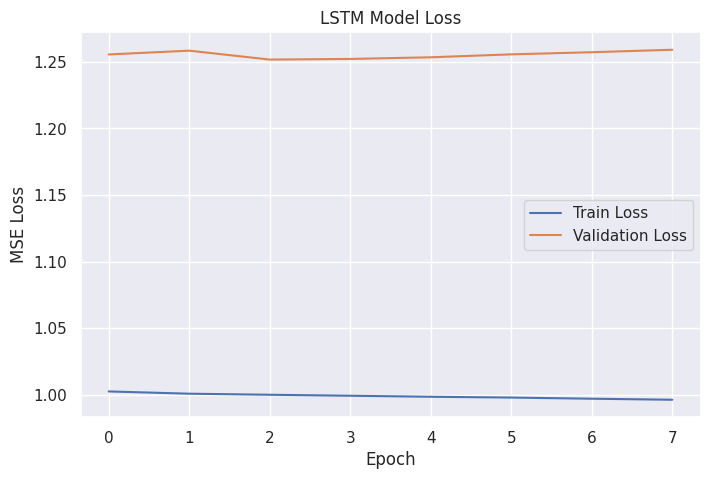

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm["train_loss"], label="Train Loss")
plt.plot(history_lstm["val_loss"], label="Validation Loss")
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [62]:
# Evaluate LSTM model

lstm_model.eval()

with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_test_seq_t.to(DEVICE)).cpu().numpy().flatten()

y_true_lstm_scaled = y_test_seq_t.cpu().numpy().flatten()

# Convert back to original return scale
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_true_lstm = target_scaler.inverse_transform(y_true_lstm_scaled.reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 0.00021768943406641483
LSTM RMSE: 0.0003378846893094587


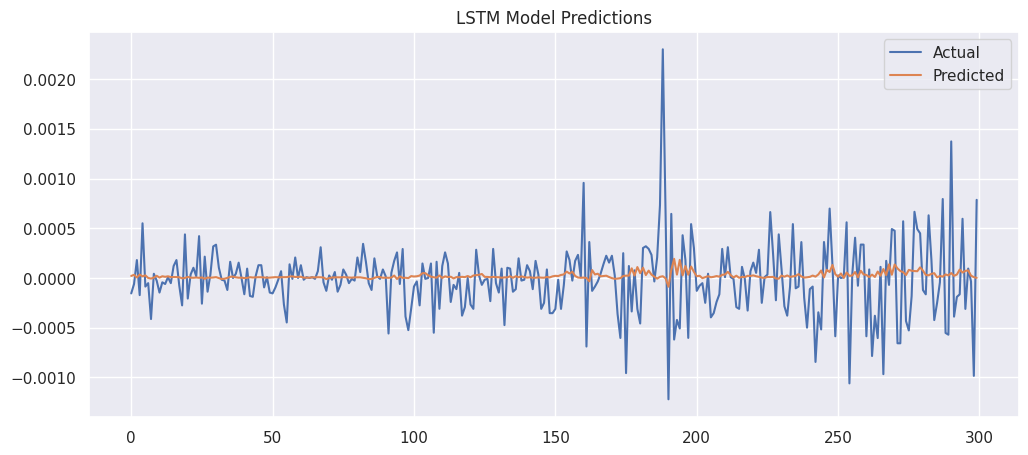

In [63]:
plt.figure(figsize=(12, 5))
plt.plot(y_true_lstm[:300], label="Actual")
plt.plot(y_pred_lstm[:300], label="Predicted")
plt.title("LSTM Model Predictions")
plt.legend()
plt.show()

In [64]:
comparison_dense_lstm = pd.DataFrame({
    "model_name": ["Dense", "LSTM"],
    "MAE": [mae_dense, mae_lstm],
    "RMSE": [rmse_dense, rmse_lstm]
})

comparison_dense_lstm

,model_name,MAE,RMSE
0,Dense,0.000221,0.000344
1,LSTM,0.000218,0.000338


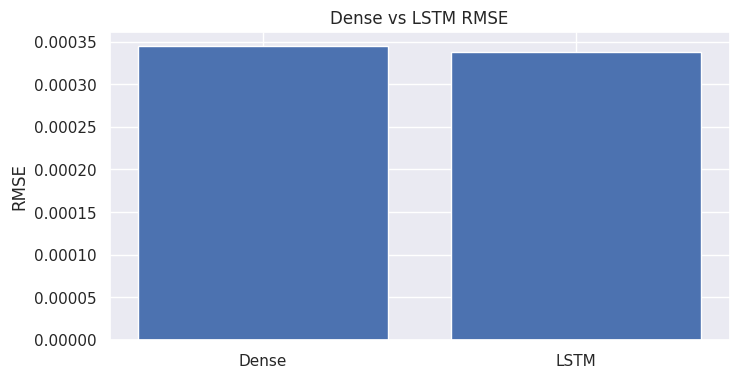

In [65]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_dense_lstm["model_name"], comparison_dense_lstm["RMSE"])
plt.title("Dense vs LSTM RMSE")
plt.ylabel("RMSE")
plt.show()

#### Section 5: GRU Model

In [66]:
# Convert sequence data to tensors (GRU)

X_train_gru_t = torch.tensor(X_train, dtype=torch.float32)
y_train_gru_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_gru_t = torch.tensor(X_val, dtype=torch.float32)
y_val_gru_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_gru_t = torch.tensor(X_test, dtype=torch.float32)
y_test_gru_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [67]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_gru = TensorDataset(X_train_gru_t, y_train_gru_t)
val_dataset_gru = TensorDataset(X_val_gru_t, y_val_gru_t)

train_loader_gru = DataLoader(train_dataset_gru, batch_size=BATCH_SIZE, shuffle=False)
val_loader_gru = DataLoader(val_dataset_gru, batch_size=BATCH_SIZE, shuffle=False)

In [68]:
# GRU Model

class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, hidden = self.gru(x)
        out = hidden[-1]
        out = self.fc(out)
        return out

In [69]:
# Initialize GRU

input_size = X_train.shape[2]

gru_model = GRURegressor(
    input_size=input_size,
    hidden_size=64,
    num_layers=1
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

print(gru_model)

GRURegressor(
  (gru): GRU(10, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [70]:
history_gru = train_regression_model(
    model=gru_model,
    train_loader=train_loader_gru,
    val_loader=val_loader_gru,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    patience=5
)

Epoch 1: Train 1.003697, Val 1.253212
Epoch 2: Train 1.001145, Val 1.259732
Epoch 3: Train 1.000845, Val 1.259250
Epoch 4: Train 1.000292, Val 1.255762
Epoch 5: Train 0.999815, Val 1.255555
Epoch 6: Train 0.999302, Val 1.257433
Early stopping triggered


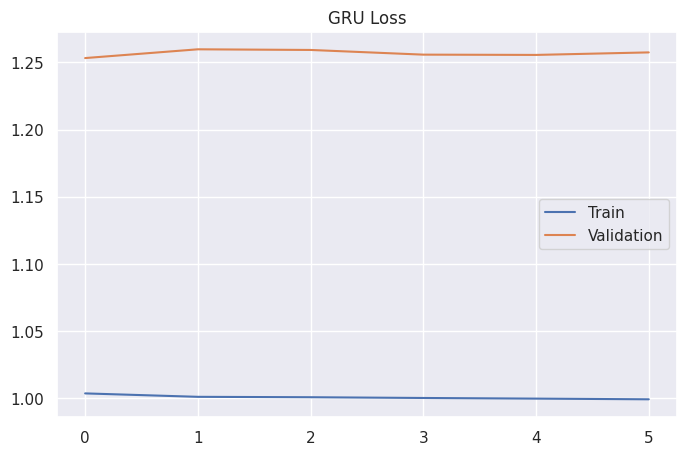

In [71]:
plt.figure(figsize=(8,5))
plt.plot(history_gru["train_loss"], label="Train")
plt.plot(history_gru["val_loss"], label="Validation")
plt.title("GRU Loss")
plt.legend()
plt.show()

In [72]:
gru_model.eval()

with torch.no_grad():
    y_pred_gru_scaled = gru_model(X_test_gru_t.to(DEVICE)).cpu().numpy().flatten()

y_true_gru_scaled = y_test_gru_t.cpu().numpy().flatten()

# Inverse transform
y_pred_gru = target_scaler.inverse_transform(y_pred_gru_scaled.reshape(-1,1)).flatten()
y_true_gru = target_scaler.inverse_transform(y_true_gru_scaled.reshape(-1,1)).flatten()

mae_gru = mean_absolute_error(y_true_gru, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_true_gru, y_pred_gru))

print("GRU MAE:", mae_gru)
print("GRU RMSE:", rmse_gru)

GRU MAE: 0.0002171780652133748
GRU RMSE: 0.0003371213100321251


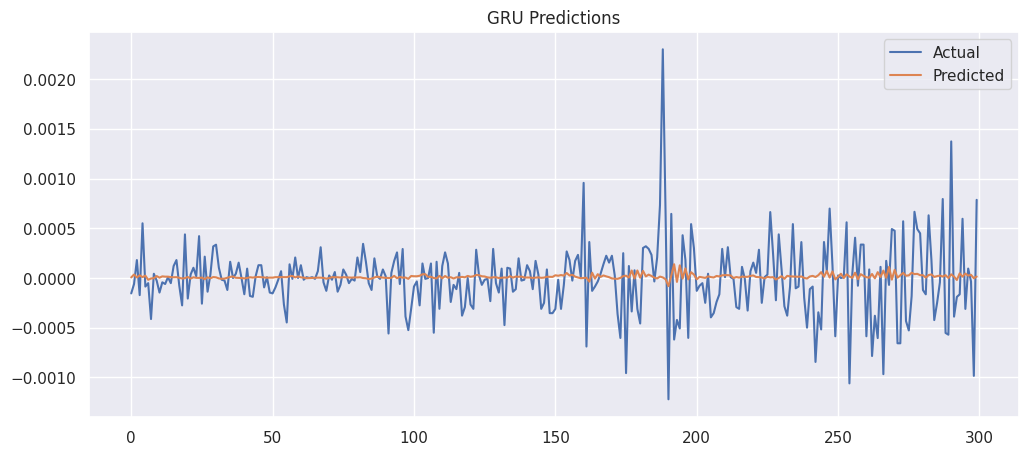

In [73]:
plt.figure(figsize=(12,5))
plt.plot(y_true_gru[:300], label="Actual")
plt.plot(y_pred_gru[:300], label="Predicted")
plt.title("GRU Predictions")
plt.legend()
plt.show()

In [74]:
comparison_all = pd.DataFrame({
    "model_name": ["Dense", "LSTM", "GRU"],
    "MAE": [mae_dense, mae_lstm, mae_gru],
    "RMSE": [rmse_dense, rmse_lstm, rmse_gru]
}).sort_values(by="RMSE")

comparison_all

,model_name,MAE,RMSE
2,GRU,0.000217,0.000337
1,LSTM,0.000218,0.000338
0,Dense,0.000221,0.000344


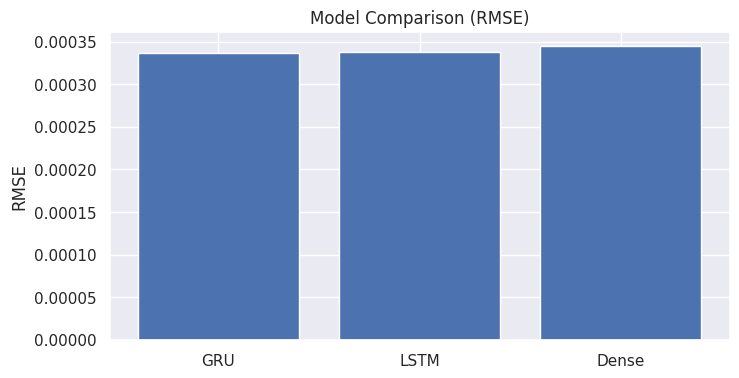

In [75]:
plt.figure(figsize=(8,4))
plt.bar(comparison_all["model_name"], comparison_all["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

#### Section 6: Hyperparameter Optimization and Final Comparision

In [76]:
# GRU hyperparameter search space

gru_param_grid = [
    {"hidden_size": 32, "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 64, "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 64, "num_layers": 2, "lr": 1e-3},
    {"hidden_size": 64, "num_layers": 1, "lr": 5e-4},
    {"hidden_size": 128, "num_layers": 1, "lr": 5e-4},
]

In [77]:
# GRU tuning

tuning_results = []

best_val_loss = float("inf")
best_model = None
best_config = None
best_history = None

for i, params in enumerate(gru_param_grid):

    print(f"\nRunning config {i+1}: {params}", flush=True)

    model = GRURegressor(
        input_size=X_train.shape[2],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"]
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.MSELoss()

    history = train_regression_model(
        model,
        train_loader_gru,
        val_loader_gru,
        criterion,
        optimizer,
        DEVICE,
        EPOCHS,
        patience=5
    )

    final_train_loss = history["train_loss"][-1]
    final_val_loss = history["val_loss"][-1]

    tuning_results.append({
        "hidden_size": params["hidden_size"],
        "num_layers": params["num_layers"],
        "learning_rate": params["lr"],
        "train_loss": final_train_loss,
        "val_loss": final_val_loss
    })

    if final_val_loss < best_val_loss:
        best_val_loss = final_val_loss
        best_model = model
        best_config = params
        best_history = history


Running config 1: {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001}
Epoch 1: Train 1.004162, Val 1.259275
Epoch 2: Train 1.002600, Val 1.275420
Epoch 3: Train 1.003883, Val 1.262167
Epoch 4: Train 1.003118, Val 1.254441
Epoch 5: Train 1.001733, Val 1.253592
Epoch 6: Train 1.000572, Val 1.254377
Epoch 7: Train 0.999979, Val 1.254800
Epoch 8: Train 0.999561, Val 1.255072
Epoch 9: Train 0.998710, Val 1.256658
Epoch 10: Train 0.998664, Val 1.256227
Early stopping triggered

Running config 2: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.001}
Epoch 1: Train 1.004088, Val 1.252143
Epoch 2: Train 1.001274, Val 1.258188
Epoch 3: Train 1.000794, Val 1.263210
Epoch 4: Train 1.000684, Val 1.260056
Epoch 5: Train 1.000494, Val 1.260903
Epoch 6: Train 0.999743, Val 1.263757
Early stopping triggered

Running config 3: {'hidden_size': 64, 'num_layers': 2, 'lr': 0.001}
Epoch 1: Train 1.004356, Val 1.253353
Epoch 2: Train 1.001825, Val 1.254620
Epoch 3: Train 1.000602, Val 1.253959
Epoch 4: Train 0.999

In [78]:
tuning_df = pd.DataFrame(tuning_results).sort_values(by="val_loss")
tuning_df

,hidden_size,num_layers,learning_rate,train_loss,val_loss
2,64,2,0.0010,0.998773,1.255665
0,32,1,0.0010,0.998664,1.256227
3,64,1,0.0005,1.000091,1.259101
1,64,1,0.0010,0.999743,1.263757
4,128,1,0.0005,0.999180,1.264314


In [79]:
print("Best configuration:", best_config)
print("Best validation loss:", best_val_loss)

Best configuration: {'hidden_size': 64, 'num_layers': 2, 'lr': 0.001}
Best validation loss: 1.2556652321230446


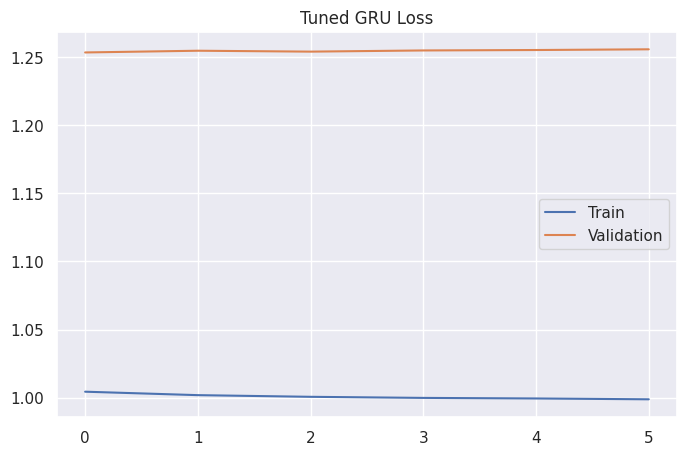

In [80]:
plt.figure(figsize=(8,5))
plt.plot(best_history["train_loss"], label="Train")
plt.plot(best_history["val_loss"], label="Validation")
plt.title("Tuned GRU Loss")
plt.legend()
plt.show()

In [81]:
best_model.eval()

with torch.no_grad():
    y_pred_tuned_scaled = best_model(X_test_gru_t.to(DEVICE)).cpu().numpy().flatten()

y_true_tuned_scaled = y_test_gru_t.cpu().numpy().flatten()

y_pred_tuned = target_scaler.inverse_transform(y_pred_tuned_scaled.reshape(-1,1)).flatten()
y_true_tuned = target_scaler.inverse_transform(y_true_tuned_scaled.reshape(-1,1)).flatten()

mae_tuned = mean_absolute_error(y_true_tuned, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_true_tuned, y_pred_tuned))

print("Tuned GRU MAE:", mae_tuned)
print("Tuned GRU RMSE:", rmse_tuned)

Tuned GRU MAE: 0.00021629811089951545
Tuned GRU RMSE: 0.00033654296275435156


In [82]:
final_comparison = pd.DataFrame({
    "model_name": ["Dense", "LSTM", "GRU", "Tuned GRU"],
    "MAE": [mae_dense, mae_lstm, mae_gru, mae_tuned],
    "RMSE": [rmse_dense, rmse_lstm, rmse_gru, rmse_tuned]
}).sort_values(by="RMSE")

final_comparison

,model_name,MAE,RMSE
3,Tuned GRU,0.000216,0.000337
2,GRU,0.000217,0.000337
1,LSTM,0.000218,0.000338
0,Dense,0.000221,0.000344


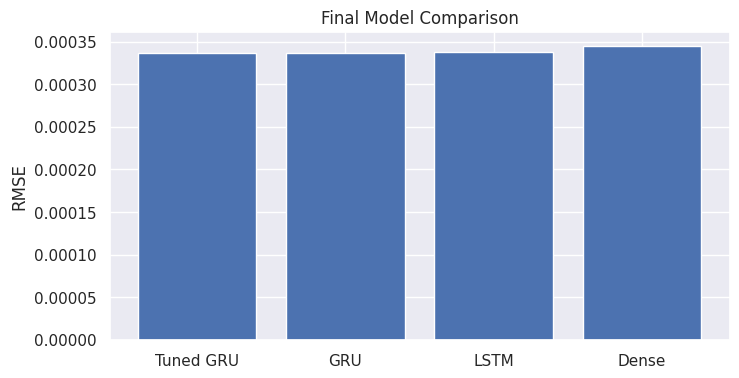

In [83]:
plt.figure(figsize=(8,4))
plt.bar(final_comparison["model_name"], final_comparison["RMSE"])
plt.title("Final Model Comparison")
plt.ylabel("RMSE")
plt.show()

In [84]:
best = final_comparison.iloc[0]

print("Best Model:", best["model_name"])
print("Best RMSE:", best["RMSE"])

Best Model: Tuned GRU
Best RMSE: 0.00033654296275435156
